In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/census-income .csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df[df.duplicated()]#to view the duplicated values

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

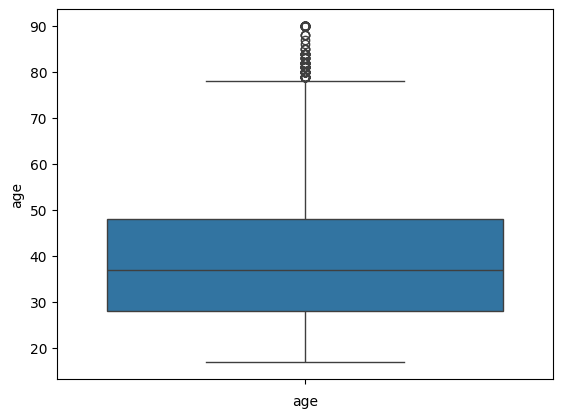

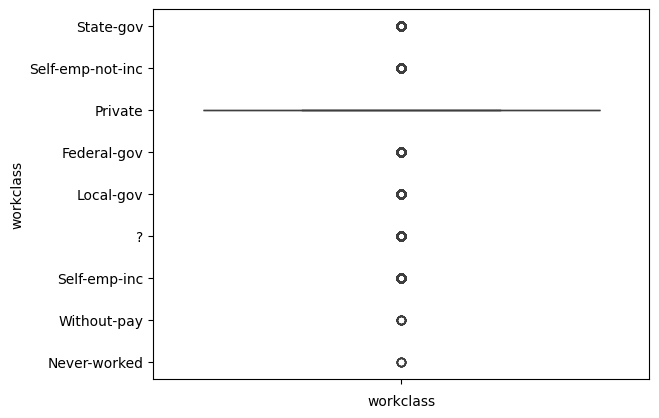

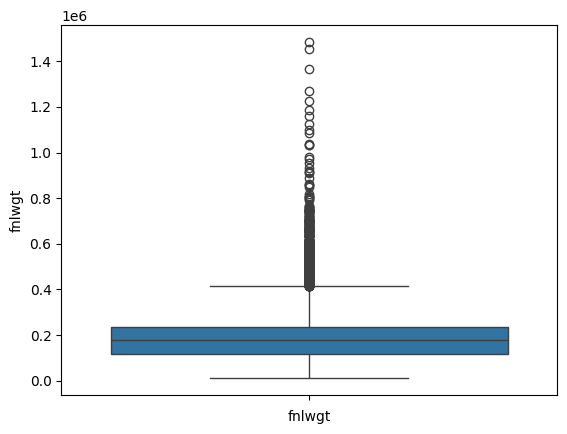

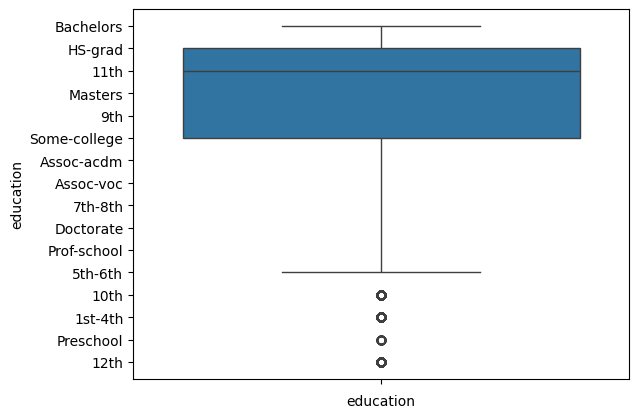

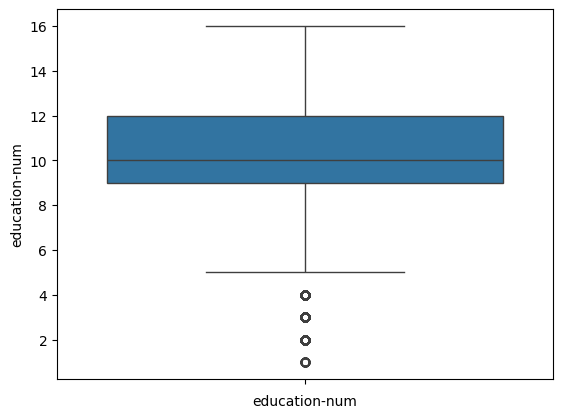

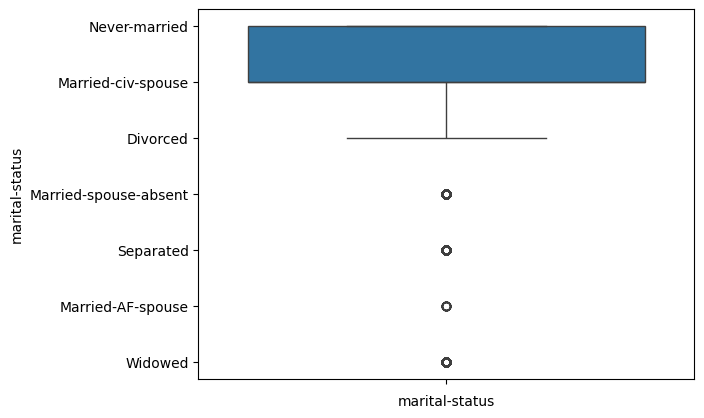

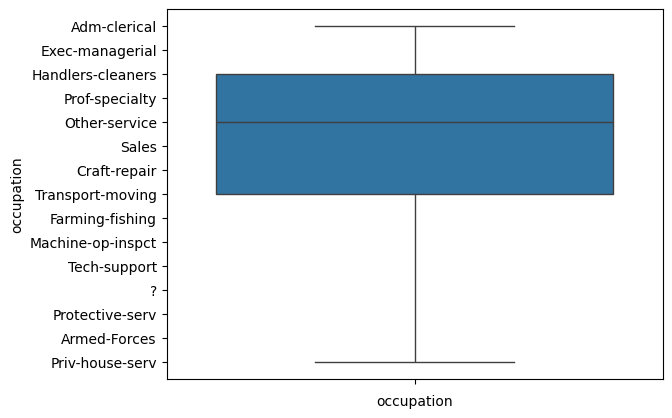

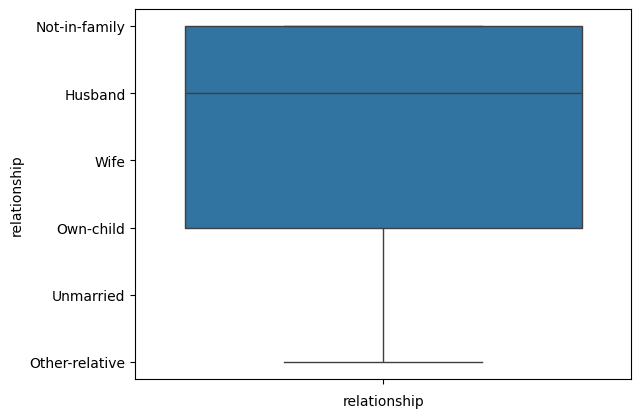

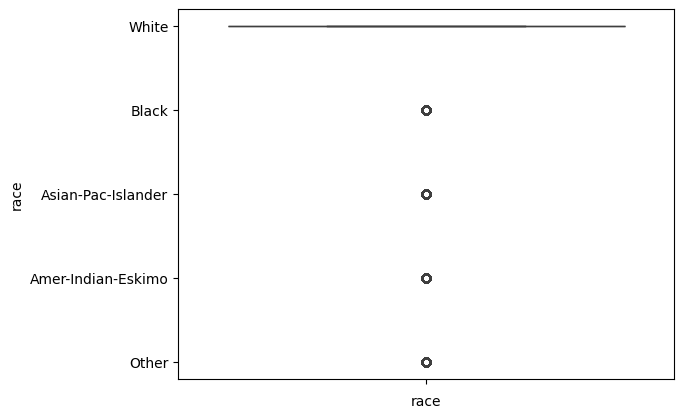

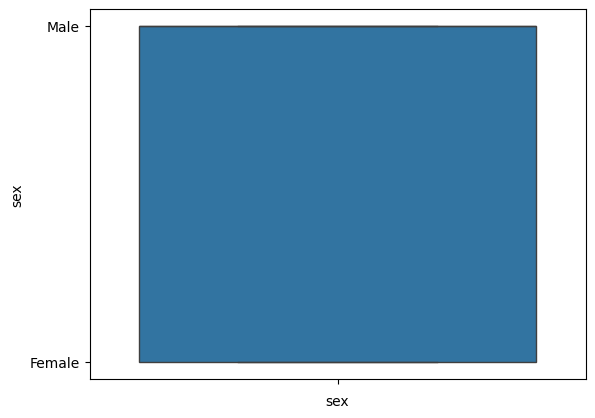

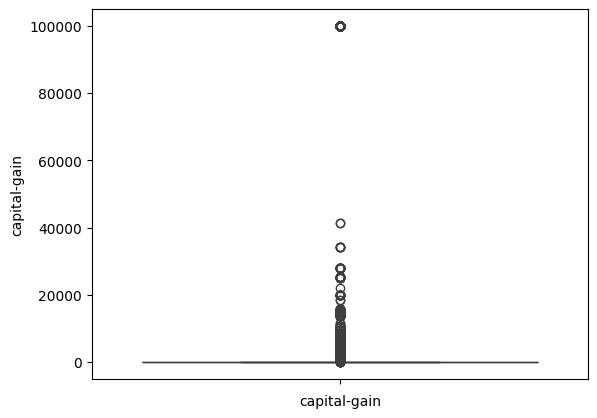

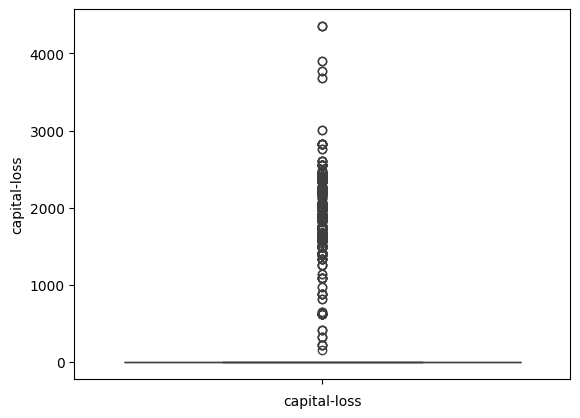

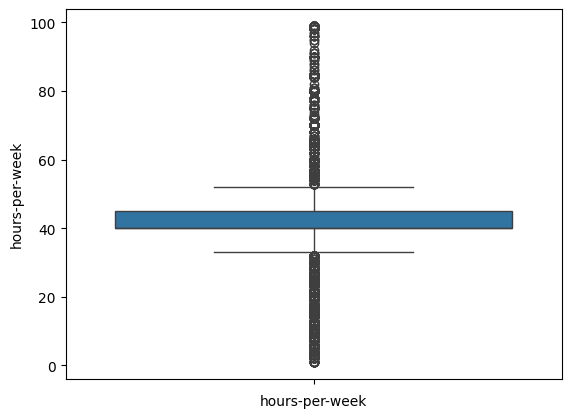

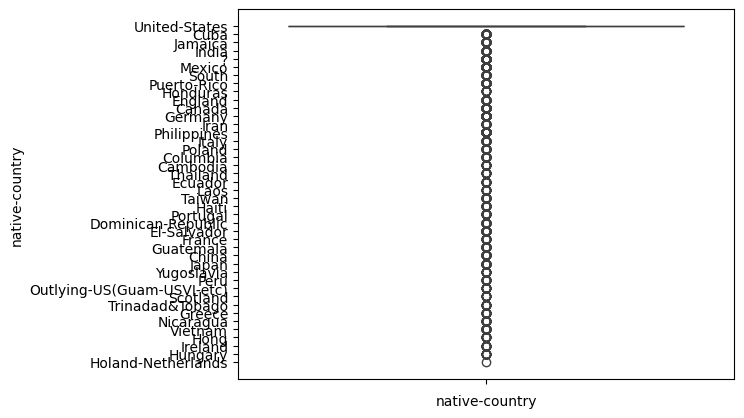

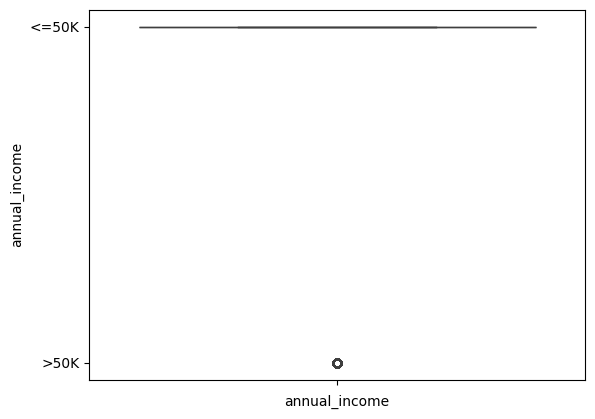

In [ ]:
for col in df.columns:
  sns.boxplot(df[col])
  plt.xlabel(col)
  plt.show()

In [ ]:
#we should not worry about ouliers in the DT model as they get ignored whil taking decision

'''out_col=['djd','dhjkv']
for col in out_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1

  lb=Q1-1.5*IQR
  up=Q3+1.5*IQR

  df=df[(df[col]>=lb)&(df[col]<=up)]'''

"out_col=['djd','dhjkv']\nfor col in out_col:\n  Q1=df[col].quantile(0.25)\n  Q3=df[col].quantile(0.75)\n\n  IQR=Q3-Q1\n\n  lb=Q1-1.5*IQR\n  up=Q3+1.5*IQR\n\n  df=df[(df[col]>=lb)&(df[col]<=up)]"

In [ ]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object': # It's also best practice to only encode object/string columns
        df[col] = LE.fit_transform(df[col])

In [ ]:
# model building
# 1.split the data in terms of x and y
# 2.split in terms of train and test
# 3.model initialization
# 4.train the model
# 5.prediction by model
# 6.evaluate , accuracy
# 7.hyperparameter tuning
# 8.visualize the tree

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  int64
 14  annual_income   32537 non-null  int64
dtypes: int64(15)
memory usage: 4.0 MB


In [ ]:
x=df.drop('annual_income',axis=1)
y=df['annual_income']

In [ ]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39


In [ ]:
y

,annual_income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,1
32558,0
32559,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=34)

In [ ]:
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
6670,19,4,27433,1,7,4,6,1,4,1,0,0,40,39
6188,33,4,195488,11,9,2,1,5,4,0,0,0,52,39
16716,55,6,248841,12,14,2,10,0,4,1,0,1977,40,39
456,30,4,180374,11,9,2,4,5,4,0,0,0,40,39
12302,37,6,174308,11,9,2,3,0,4,1,0,0,40,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28424,18,4,761006,1,7,4,8,3,4,0,0,0,20,39
22391,38,4,331395,5,4,2,5,0,4,1,3942,0,84,32
10733,37,4,208391,15,10,2,14,0,4,1,0,0,40,39
5244,58,4,142182,11,9,2,3,0,4,1,0,0,25,39


In [ ]:
y_train

,annual_income
6670,0
6188,0
16716,1
456,0
12302,0
...,...
28424,0
22391,0
10733,1
5244,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model=DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test

,annual_income
18833,0
13906,0
6704,0
19460,0
6527,0
...,...
13234,0
2494,0
6820,0
26575,0


In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,y_pred)*100


81.02335586969883

In [ ]:
confusion_matrix(y_test,y_pred)

array([[4287,  674],
       [ 561,  986]])

In [ ]:
from sklearn.tree import plot_tree

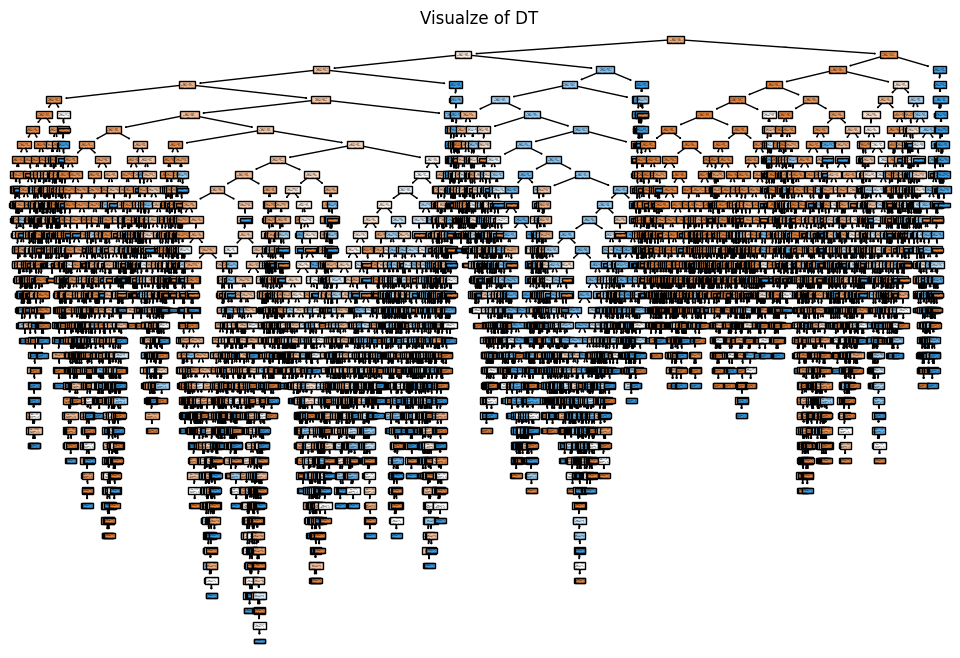

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model,filled=True)
plt.title('Visualze of DT')
plt.show()

In [ ]:
depth=[1,2,3,4,5,6,7,8,9,10]
for i in depth:
  temp_model=DecisionTreeClassifier(max_depth=i)
  temp_model.fit(x_train,y_train)
  y_pred_temp=temp_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred_temp)
  print(f"For the max depth {i} the accuracy of the model is {acc}")

For the max depth 1 the accuracy of the model is 0.7622925629993854
For the max depth 2 the accuracy of the model is 0.8211432083589428
For the max depth 3 the accuracy of the model is 0.835279655808236
For the max depth 4 the accuracy of the model is 0.8395820528580209
For the max depth 5 the accuracy of the model is 0.8464966195451752
For the max depth 6 the accuracy of the model is 0.8492624462200369
For the max depth 7 the accuracy of the model is 0.8526429010448678
For the max depth 8 the accuracy of the model is 0.8511063306699447
For the max depth 9 the accuracy of the model is 0.8435771358328211
For the max depth 10 the accuracy of the model is 0.8461893054701906


In [ ]:
final_model=DecisionTreeClassifier(max_depth=7)
final_model.fit(x_train,y_train)
y_pred_final=final_model.predict(x_test)

accuracy_score(y_test,y_pred_final)*100

85.2181929932391

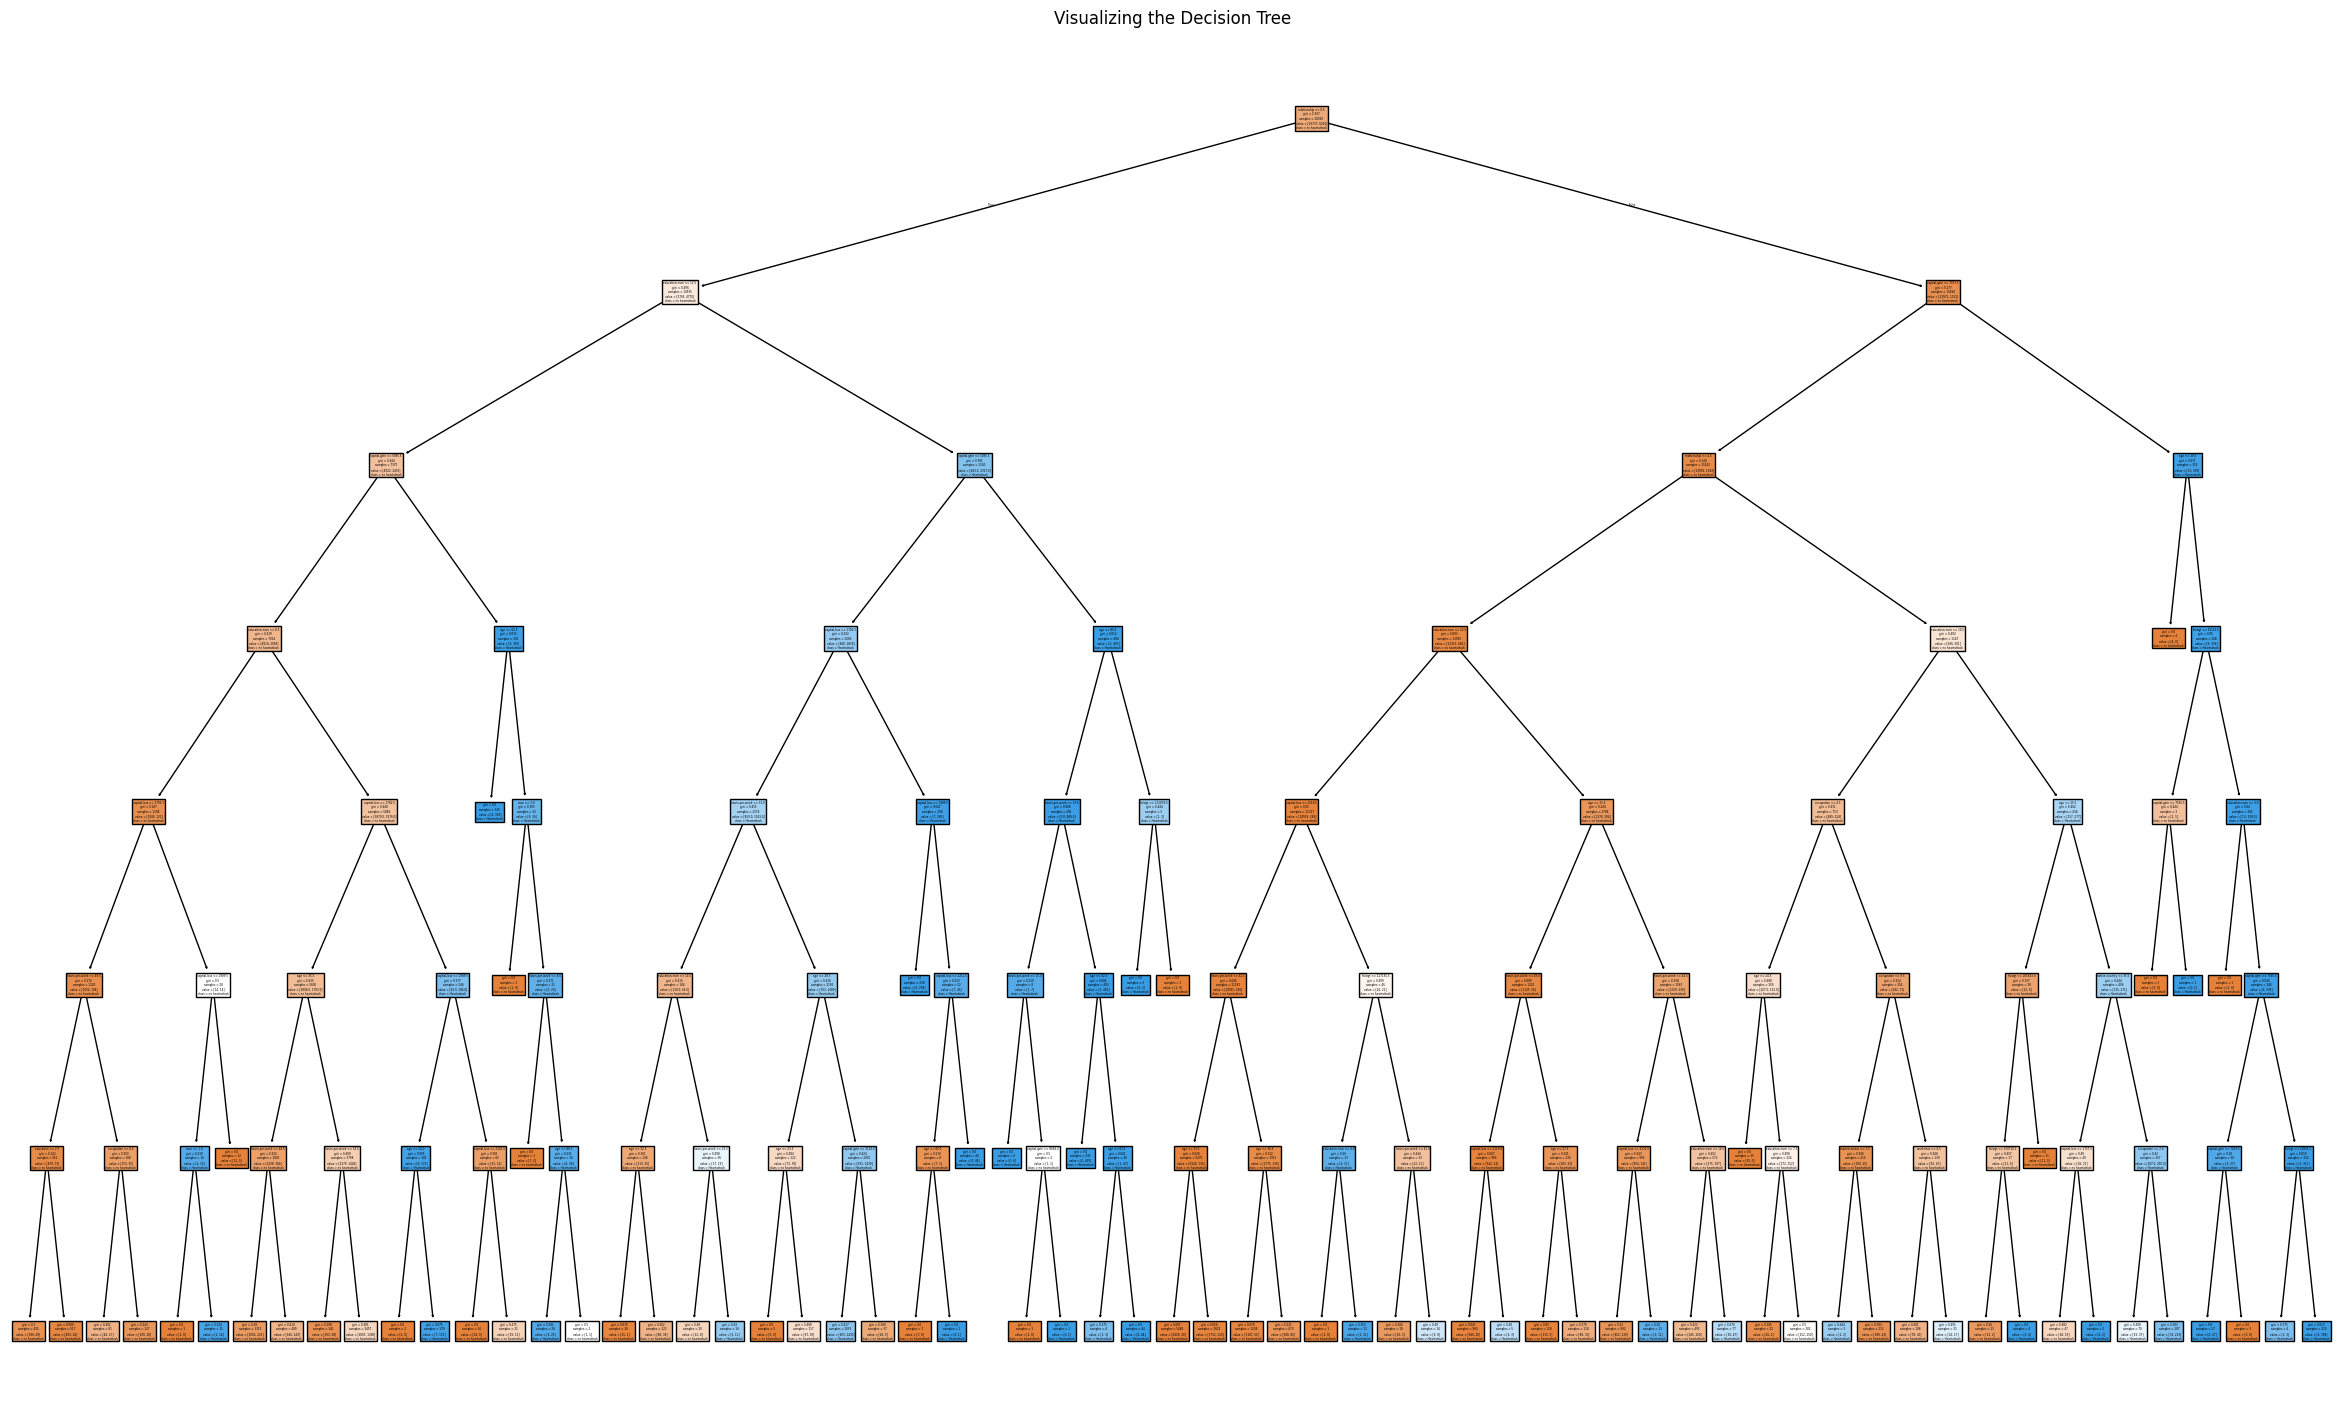

In [ ]:
plt.figure(figsize=(30,18))
plot_tree(final_model,filled=True,feature_names=x.columns,class_names=['no heartattack','Heartattack'])
plt.title("Visualizing the Decision Tree")
plt.show()